# Dataset: **Diabetes** (scikit-learn)
442 real patients, 10 characteristics.

> Rule: Everything built from scratch with NumPy; scikit-learn added last.

## Part 0 (Setup & Dataset)

### `load_diabetes(scaled=False)`
Raw values. Requires `numpy`, `pandas`, `matplotlib`, `plotly`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes

# Reproducibility: same random numbers for everyone
rng = np.random.default_rng(42)

# NumPy and pandas should print width without splitting rows or using scientific notation.
np.set_printoptions(linewidth=140, suppress=True, precision=3)
pd.set_option("display.width", 140)

data = load_diabetes(scaled=False)
X_full = data.data                  # (442, 10) characteristics
y = data.target                     # (442,) disease progression

print(f"{X_full.shape[0]} | Characteristics: {X_full.shape[1]}")

# We see it as a table: much more readable than a raw array
df = pd.DataFrame(X_full, columns=data.feature_names)
df["progression"] = y
df.head()

442 | Characteristics: 10


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,progression
0,59.0,2.0,32.1,101.0,157.0,93.2,38.0,4.0,4.8598,87.0,151.0
1,48.0,1.0,21.6,87.0,183.0,103.2,70.0,3.0,3.8918,69.0,75.0
2,72.0,2.0,30.5,93.0,156.0,93.6,41.0,4.0,4.6728,85.0,141.0
3,24.0,1.0,25.3,84.0,198.0,131.4,40.0,5.0,4.8903,89.0,206.0
4,50.0,1.0,23.0,101.0,192.0,125.4,52.0,4.0,4.2905,80.0,135.0


### Beware of the very different scales of the columns (`s1` up to 301, `s4` from 2 to 9).

In [2]:
df.describe().round(1)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,progression
count,442.0,442.0,442.0,442.0,442.0,442.0,442.0,442.0,442.0,442.0,442.0
mean,48.5,1.5,26.4,94.6,189.1,115.4,49.8,4.1,4.6,91.3,152.1
std,13.1,0.5,4.4,13.8,34.6,30.4,12.9,1.3,0.5,11.5,77.1
min,19.0,1.0,18.0,62.0,97.0,41.6,22.0,2.0,3.3,58.0,25.0
25%,38.2,1.0,23.2,84.0,164.2,96.0,40.2,3.0,4.3,83.2,87.0
50%,50.0,1.0,25.7,93.0,186.0,113.0,48.0,4.0,4.6,91.0,140.5
75%,59.0,2.0,29.3,105.0,209.8,134.5,57.8,5.0,5.0,98.0,211.5
max,79.0,2.0,42.2,133.0,301.0,242.4,99.0,9.1,6.1,124.0,346.0


One single feature required for graphing: **BMI**

$$\hat{y} = \theta_0 + \theta_1 * x_{bmi}$$

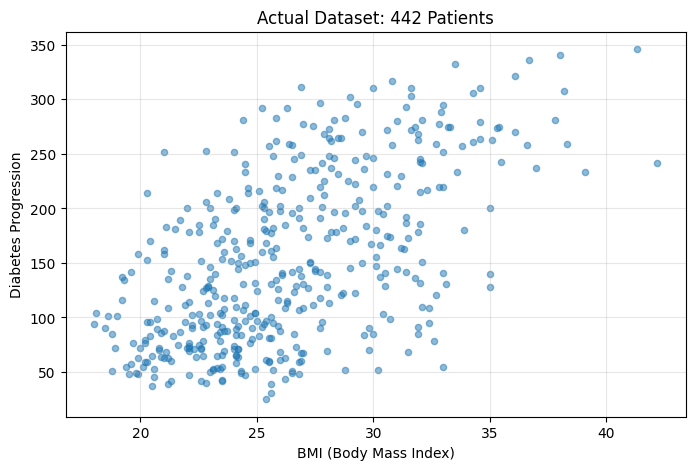

BMI → min: 18.0 | max: 42.2 | mean: 26.4
y   → min: 25 | max: 346 | mean: 152.1


In [3]:
# We select the BMI feature (column 2)

x_bmi = X_full[:, 2]

plt.figure(figsize=(8, 5))
plt.scatter(x_bmi, y, alpha=0.5, s=20)
plt.xlabel("BMI (Body Mass Index)")
plt.ylabel("Diabetes Progression")
plt.title("Actual Dataset: 442 Patients")
plt.grid(alpha=0.3)
plt.show()

print(f"BMI → min: {x_bmi.min():.1f} | max: {x_bmi.max():.1f} | mean: {x_bmi.mean():.1f}")
print(f"y   → min: {y.min():.0f} | max: {y.max():.0f} | mean: {y.mean():.1f}")

---

## Part 1: The cost function (MSE)

$$J (\theta) = MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

In [4]:
def predict(X, theta):
    '''
        Model prediction: X already includes the column of 1s for theta_0 (the bias)
    '''
    return X @ theta

def mse(X, y, theta):
    '''
        Cost function: how bad are we doing with this combination of thetas
    '''
    errors = predict(X, theta) - y
    return np.mean(errors ** 2)

# Design matrix: column of 1s (for theta_0) + BMI
m = len(y)
X = np.column_stack([np.ones(m), x_bmi])        # (442, 2)
print("X with bias:", X.shape)
print(X[:3])

X with bias: (442, 2)
[[ 1.  32.1]
 [ 1.  21.6]
 [ 1.  30.5]]


### 1.1 The parabola: sweep of $\theta_1$

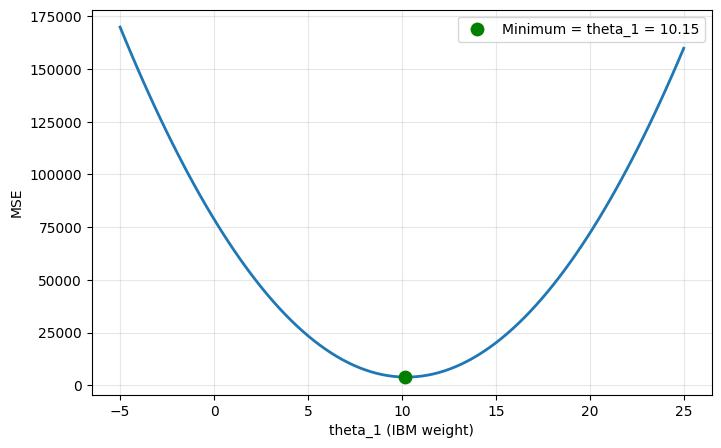

In [5]:
# Sweep of theta_1 (setting theta_0 = -117.8, close to its actual optimum)
theta_0_fixed = -117.8
values_theta1 = np.linspace(-5, 25, 100)
costs = [mse(X, y, np.array([theta_0_fixed, t1])) for t1 in values_theta1]

# Which was better?
best_t1 = values_theta1[np.argmin(costs)]

plt.figure(figsize=(8, 5))
plt.plot(values_theta1, costs, lw=2)
plt.scatter([best_t1], [min(costs)], color="green", zorder=5, s=80,
            label=f"Minimum = theta_1 = {best_t1:.2f}")
plt.xlabel("theta_1 (IBM weight)")
plt.ylabel("MSE")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

> Convex MSE → a single global minimum

### The 3D surface and contours

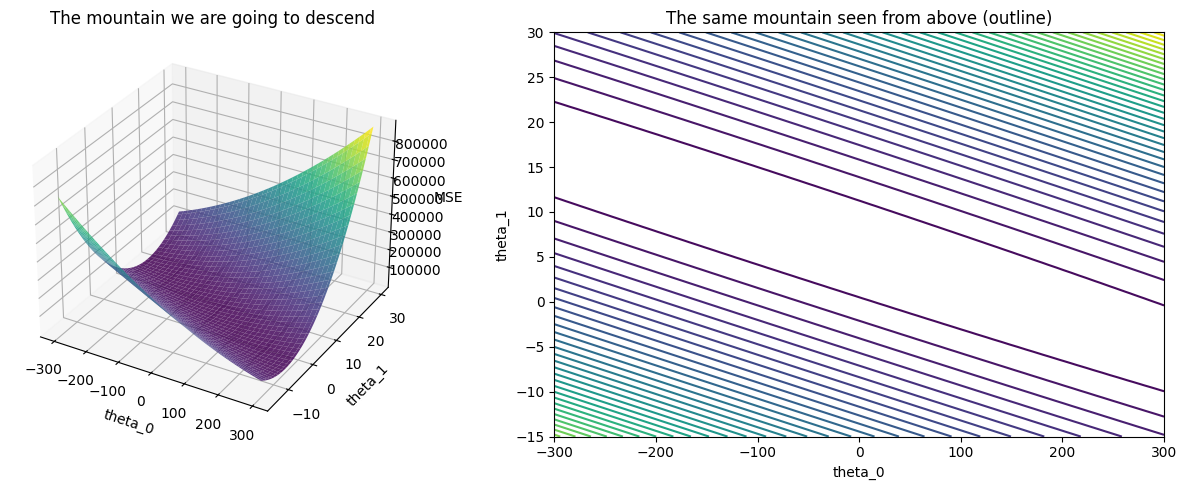

In [6]:
from mpl_toolkits.mplot3d import Axes3D

t0_grid = np.linspace(-300, 300, 80)
t1_grid = np.linspace(-15, 30, 80)
T0, T1 = np.meshgrid(t0_grid, t1_grid)
Z = np.zeros_like(T0)

for i in range(T0.shape[0]):
    for j in range(T0.shape[1]):
        Z[i, j] = mse(X, y, np.array([T0[i, j], T1[i, j]]))

fig = plt.figure(figsize=(13, 5))

ax = fig.add_subplot(1, 2, 1, projection="3d")
ax.plot_surface(T0, T1, Z, cmap ="viridis", alpha=0.85)
ax.set_xlabel("theta_0")
ax.set_ylabel("theta_1")
ax.set_zlabel("MSE")
ax.set_title("The mountain we are going to descend")

ax2 = fig.add_subplot(1, 2, 2)
cont = ax2.contour(T0, T1, Z, levels=40, cmap="viridis")
ax2.set_xlabel("theta_0")
ax2.set_ylabel("theta_1")
ax2.set_title("The same mountain seen from above (outline)")
plt.tight_layout()
plt.show()

## Part 2 Batch Gradient Descent from Zero

Start random → measure error → gradient → reverse step → repeat

$$\nabla_{\theta} J = \frac{2}{m} X^{T} ({X \theta - y})$$

Batch: The entire dataset per update. **1 epoch = 1 step.**

In [7]:
def gradient(X, y, theta):
    '''
        The compass: it points towards where the cost INCREASES.
    '''
    m = len(y)
    return (2 / m ) * X.T @ (predict(X, theta) - y)

def batch_gd(X, y, lr=0.01, epoch=100, theta_initial=None, seed=42):
    rng = np.random.default_rng(seed)
    theta = rng.uniform(-1, 1, X.shape[1]) if theta_initial is None else theta_initial.copy()

    history_theta = [theta.copy()]
    history_cost = [mse(X, y, theta)]

    for _ in range(epoch):
        grad = gradient(X, y, theta)        # 1 gradient with ALL records
        theta = theta - lr * grad           # 1 epoch = 1 step
        history_theta.append(theta.copy())
        history_cost.append(mse(X, y, theta))

    return theta, np.array(history_theta), np.array(history_cost)

## 2.1 First attempt with raw data

In [8]:
theta_final, _, crude_costs = batch_gd(X, y, lr=0.01, epoch=20)

print("Cost per period (unstandardized data)")
for i, c, in enumerate(crude_costs[:8]):
    print(f"    Epoch{i}: MSE = {c:,.2f}")

Cost per period (unstandardized data)
    Epoch0: MSE = 29,944.99
    Epoch1: MSE = 4,560,823.74
    Epoch2: MSE = 808,756,155.27
    Epoch3: MSE = 143,547,087,530.77
    Epoch4: MSE = 25,478,475,598,686.02
    Epoch5: MSE = 4,522,228,553,018,301.00
    Epoch6: MSE = 802,659,916,207,023,744.00
    Epoch7: MSE = 142,465,807,186,163,154,944.00


The cost **explodes**: disparate scales → **standardize** (mean 0, standard deviation 1).

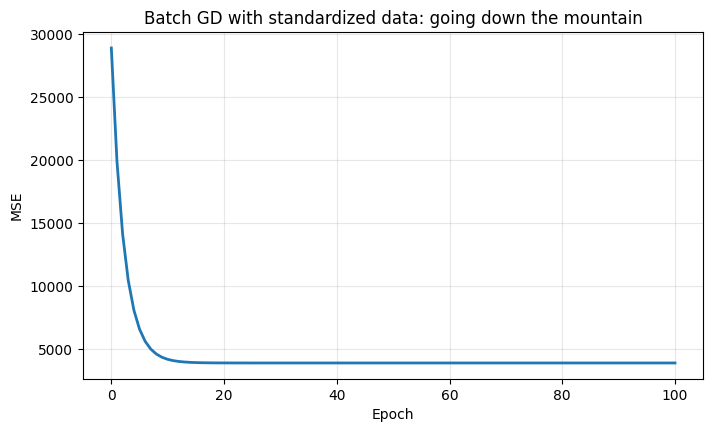

theta final: theta_0 = 152.13, theta_1 = 45.16
MSE final: 3890.46


In [9]:
# We standardize the characteristic (the bias remains at 1s)
mean_bmi, std_bmi = x_bmi.mean(), x_bmi.std()
x_est = (x_bmi - mean_bmi) / std_bmi
X_est = np.column_stack([np.ones(m), x_est])

theta_final, theta_hist, cost_hist = batch_gd(X_est, y, lr=0.1, epoch=100)

plt.figure(figsize=(8, 4.5))
plt.plot(cost_hist, lw=2)
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Batch GD with standardized data: going down the mountain")
plt.grid(alpha=0.3)
plt.show()

print(f"theta final: theta_0 = {theta_final[0]:.2f}, theta_1 = {theta_final[1]:.2f}")
print(f"MSE final: {cost_hist[-1]:.2f}")